# RSNA DICOM Service MVP — Training Notebook

Main training notebook for the course project. It focuses on the **model pipeline** that feeds the AI service.

## Notebook purpose
1. Prepare the training data and define the binary task.
2. Train and validate the chest X-ray classification model.
3. Calibrate the model outputs and select the operating threshold.
4. Generate Grad-CAM visual evidence for model inspection.
5. Export the artifacts consumed by the runtime service.
6. Keep a local inference demo only as a model sanity check.




## Scope boundary
- **Inside this notebook**: data preparation, training, evaluation, calibration, Grad-CAM, artifact export, and local model demonstration.
- **Outside this notebook**: backend runtime logic, API endpoints, Streamlit client behavior, Orthanc integration, OHIF integration, and any external service orchestration.

## Minimal Drive structure
```text
rsna_service_v3/
├─ 01_notebook/
├─ 02_data/
│  ├─ raw/
│  └─ prepared/
├─ 03_artifacts/
├─ 04_service/ [DEPRECATED]
├─ 05_docs/
│  ├─ figures/
│  └─ tables/
└─ README.md
```

## Execution notes
- Long-running stages persist checkpoints and intermediate artifacts in Drive.
- The notebook avoids mixing training logic with backend/runtime integration logic.
- Descriptive text and comments should stay aligned with the current notebook contents and not with older service-oriented versions.
- kaggle.json token for kaggle is needed for ds ingestion. See Block 1.

## BLOCK 0. Project configuration

**Role in the project**
- Defines persistent paths and prevents the ephemeral `/content` directory from breaking the workflow.
- Stores all important artifacts in Drive.


In [1]:

# Mount Google Drive and define the persistent project structure
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import json, os, sys, platform, time
from datetime import datetime

PROJECT_ROOT = Path("/content/drive/MyDrive/rsna_service_v3")
NOTEBOOK_DIR = PROJECT_ROOT / "01_notebook"
DATA_RAW_DIR = PROJECT_ROOT / "02_data" / "raw"
DATA_PREP_DIR = PROJECT_ROOT / "02_data" / "prepared"
ARTIFACTS_DIR = PROJECT_ROOT / "03_artifacts"
CHECKPOINTS_DIR = ARTIFACTS_DIR / "checkpoints"
#SERVICE_DIR = PROJECT_ROOT / "04_service"
DOCS_DIR = PROJECT_ROOT / "05_docs"
FIGURES_DIR = DOCS_DIR / "figures"
TABLES_DIR = DOCS_DIR / "tables"

for p in [
    NOTEBOOK_DIR, DATA_RAW_DIR, DATA_PREP_DIR, ARTIFACTS_DIR,
    CHECKPOINTS_DIR, DOCS_DIR, FIGURES_DIR, TABLES_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.version.split()[0], "| Platform:", platform.platform())


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/rsna_service_v3
Python: 3.12.13 | Platform: Linux-6.6.122+-x86_64-with-glibc2.35


In [2]:

# Dependencies and versions
# Install only what is needed while keeping the runtime-compatible torch/torchvision setup.

import importlib, subprocess, pkgutil

REQUIRED = {
    "pydicom": "2.4.4",
    "PIL": "10.4.0",              # Pillow package
    "cv2": "4.10.0.84",           # opencv-python-headless package
    "multipart": "0.0.9",         # python-multipart package
    "sklearn": "1.5.2",           # scikit-learn package
    "numpy": "1.26.4",
    "fastapi": "0.115.0",
    "uvicorn": "0.30.6",
    "requests": "2.32.3",
    "tqdm": "4.66.5",
    "pandas": "2.2.2",
    "matplotlib": "3.8.0",
}

PIP_NAMES = {
    "PIL": "pillow",
    "cv2": "opencv-python-headless",
    "multipart": "python-multipart",
    "sklearn": "scikit-learn",
}

def ensure_pkg(import_name: str, version: str):
    if pkgutil.find_loader(import_name) is None:
        pip_name = PIP_NAMES.get(import_name, import_name)
        print(f"Instalando {pip_name}=={version} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", f"{pip_name}=={version}"])

for import_name, version in REQUIRED.items():
    ensure_pkg(import_name, version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
from PIL import Image
import cv2
import sklearn
import fastapi
import uvicorn
import torch
import torchvision

versions = {
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "pydicom": pydicom.__version__,
    "opencv": cv2.__version__,
    "sklearn": sklearn.__version__,
    "fastapi": fastapi.__version__,
}
print(json.dumps(versions, indent=2))

runtime_manifest_path = ARTIFACTS_DIR / "runtime_manifest.json"
runtime_manifest_path.write_text(json.dumps(versions, indent=2), encoding="utf-8")
print("Saved:", runtime_manifest_path)

Instalando pydicom==2.4.4 ...


/tmp/ipykernel_547/574990177.py:29: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader(import_name) is None:


{
  "python": "3.12.13",
  "torch": "2.11.0+cu128",
  "torchvision": "0.26.0+cu128",
  "numpy": "2.0.2",
  "pandas": "2.2.2",
  "pydicom": "2.4.4",
  "opencv": "4.13.0",
  "sklearn": "1.6.1",
  "fastapi": "0.136.1"
}
Guardado: /content/drive/MyDrive/rsna_service_v3/03_artifacts/runtime_manifest.json


In [3]:

# Initial project manifest
run_manifest = {
    "project_name": "RSNA DICOM Service MVP",
    "created_at": datetime.utcnow().isoformat() + "Z",
    "project_root": str(PROJECT_ROOT),
    "directories": {
        "notebook": str(NOTEBOOK_DIR),
        "data_raw": str(DATA_RAW_DIR),
        "data_prepared": str(DATA_PREP_DIR),
        "artifacts": str(ARTIFACTS_DIR),
        "checkpoints": str(CHECKPOINTS_DIR),
        #"service": str(SERVICE_DIR),
        "docs": str(DOCS_DIR),
        "figures": str(FIGURES_DIR),
        "tables": str(TABLES_DIR),
    },
    "pipeline_role": "training_evaluation_calibration_and_artifact_export",
}
manifest_path = ARTIFACTS_DIR / "run_manifest.json"
manifest_path.write_text(json.dumps(run_manifest, indent=2), encoding="utf-8")
print("Saved:", manifest_path)

/tmp/ipykernel_547/1224765762.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z",


Guardado: /content/drive/MyDrive/rsna_service_v3/03_artifacts/run_manifest.json


## BLOCK 1. Data ingestion from Kaggle to Drive

**Role in the project**
- Expensive stage: download and extraction.
- Stores everything under `02_data/raw/` to avoid repeating work.

**Artifacts from this stage**
- `02_data/raw/rsna_kaggle/rsna-pneumonia-detection-challenge.zip`
- `02_data/raw/rsna_kaggle/extracted/`


In [4]:
# ============================================================
# BLOCK 1B. RSNA data in Google Drive (robust mode)
# Goal:
#   Reuse the already-downloaded structure if it exists.
#   Otherwise, download the full Kaggle package into Drive
#   and extract it without relying on individual remote filenames.
#
# Expected output in Drive:
#   rsna_service_v3/02_data/raw/rsna_kaggle/
#       stage_2_train_images/
#       stage_2_test_images/
#       stage_2_train_labels.csv
#       stage_2_detailed_class_info.csv
#
# ============================================================

import os
import json
import shutil
import subprocess
import sys
import zipfile
from pathlib import Path

# ---------- 1) Paths ----------
PROJECT_ROOT = Path("/content/drive/MyDrive/rsna_service_v3")
RAW_DIR = PROJECT_ROOT / "02_data" / "raw"
KAGGLE_DIR = RAW_DIR / "rsna_kaggle"

RAW_DIR.mkdir(parents=True, exist_ok=True)
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_IMAGES_DIR = KAGGLE_DIR / "stage_2_train_images"
TEST_IMAGES_DIR = KAGGLE_DIR / "stage_2_test_images"
TRAIN_LABELS_CSV = KAGGLE_DIR / "stage_2_train_labels.csv"
DETAILED_INFO_CSV = KAGGLE_DIR / "stage_2_detailed_class_info.csv"

# ---------- 2) Check whether the dataset is already prepared ----------
def dataset_ready():
    return (
        TRAIN_IMAGES_DIR.exists()
        and TRAIN_LABELS_CSV.exists()
        and DETAILED_INFO_CSV.exists()
    )

if dataset_ready():
    print("[OK] Dataset ya disponible en Drive. No se descarga nada.")
else:
    # ---------- 3) Locate kaggle.json ----------
    candidate_creds = [
        Path("/content/kaggle.json"),
        Path("/content/drive/MyDrive/kaggle.json"),
        Path("/content/drive/MyDrive/.kaggle/kaggle.json"),
        PROJECT_ROOT / "kaggle.json",
    ]

    kaggle_json_src = None
    for p in candidate_creds:
        if p.exists():
            kaggle_json_src = p
            break

    if kaggle_json_src is None:
        raise FileNotFoundError(
            "No encontre kaggle.json. Sube el token API a /content/kaggle.json o guardalo en MyDrive."
        )

    # ---------- 4) Install Kaggle API ----------
    print("Instalando/actualizando kaggle CLI/API...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle>=2.0.0"])

    # ---------- 5) Conf credentials ----------
    kaggle_cfg_dir = Path.home() / ".kaggle"
    kaggle_cfg_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json_dst = kaggle_cfg_dir / "kaggle.json"
    shutil.copy2(kaggle_json_src, kaggle_json_dst)
    os.chmod(kaggle_json_dst, 0o600)

    with open(kaggle_json_dst, "r") as f:
        creds = json.load(f)
    print("Usuario en kaggle.json:", creds.get("username"))

# ---------- 6) Download the full competition package ----------
    # Mucho mas robusto que intentar adivinar nombres concretos.
    from kaggle.api.kaggle_api_extended import KaggleApi

    api = KaggleApi()
    api.authenticate()

    competition_name = "rsna-pneumonia-detection-challenge"

    print("Downloading the full competition package to Drive...")
    api.competition_download_files(
        competition=competition_name,
        path=str(KAGGLE_DIR),
        force=False,
        quiet=False
    )

    # ---------- 7) Extraer todos los zips presentes ----------
    zip_files = sorted(KAGGLE_DIR.glob("*.zip"))
    print(f"ZIP files found for extraction: {len(zip_files)}")
    for zpath in zip_files:
        print(f"Extracting {zpath.name} ...")
        with zipfile.ZipFile(zpath, "r") as zf:
            zf.extractall(KAGGLE_DIR)

# ---------- 8) Validacion final ----------
print("\nChequeo final de estructura:")
print("TRAIN_IMAGES_DIR exists:", TRAIN_IMAGES_DIR.exists())
print("TEST_IMAGES_DIR exists:", TEST_IMAGES_DIR.exists())
print("TRAIN_LABELS_CSV exists:", TRAIN_LABELS_CSV.exists())
print("DETAILED_INFO_CSV exists:", DETAILED_INFO_CSV.exists())

num_train_dcm = len(list(TRAIN_IMAGES_DIR.glob("*.dcm"))) if TRAIN_IMAGES_DIR.exists() else 0
num_test_dcm = len(list(TEST_IMAGES_DIR.glob("*.dcm"))) if TEST_IMAGES_DIR.exists() else 0

print("Numero DICOM train:", num_train_dcm)
print("Numero DICOM test:", num_test_dcm)

if not TRAIN_IMAGES_DIR.exists():
    raise RuntimeError("No existe stage_2_train_images en Drive.")
if not TRAIN_LABELS_CSV.exists():
    raise RuntimeError("No existe stage_2_train_labels.csv en Drive.")
if not DETAILED_INFO_CSV.exists():
    raise RuntimeError("No existe stage_2_detailed_class_info.csv en Drive.")

print("\n[OK] Dataset is ready for the next steps.")
print("TRAIN_IMAGES_DIR =", TRAIN_IMAGES_DIR)
print("TRAIN_LABELS_CSV =", TRAIN_LABELS_CSV)
print("DETAILED_INFO_CSV =", DETAILED_INFO_CSV)

[OK] Dataset ya disponible en Drive. No se descarga nada.

Chequeo final de estructura:
TRAIN_IMAGES_DIR exists: True
TEST_IMAGES_DIR exists: True
TRAIN_LABELS_CSV exists: True
DETAILED_INFO_CSV exists: True
Numero DICOM train: 21499
Numero DICOM test: 3000

[OK] Dataset listo para el resto del notebook.
TRAIN_IMAGES_DIR = /content/drive/MyDrive/rsna_service_v3/02_data/raw/rsna_kaggle/stage_2_train_images
TRAIN_LABELS_CSV = /content/drive/MyDrive/rsna_service_v3/02_data/raw/rsna_kaggle/stage_2_train_labels.csv
DETAILED_INFO_CSV = /content/drive/MyDrive/rsna_service_v3/02_data/raw/rsna_kaggle/stage_2_detailed_class_info.csv


In [5]:
# Resolve dataset paths
# This cell consumes the contract defined by the robust Kaggle block:
#   TRAIN_IMAGES_DIR
#   TRAIN_LABELS_CSV
#   DETAILED_INFO_CSV

IMG_DIR = TRAIN_IMAGES_DIR
LABELS_PATH = TRAIN_LABELS_CSV
DETAILED_INFO_PATH = DETAILED_INFO_CSV

print("IMG_DIR:", IMG_DIR)
print("LABELS_PATH:", LABELS_PATH)
print("DETAILED_INFO_PATH:", DETAILED_INFO_PATH)

assert IMG_DIR is not None and IMG_DIR.exists(), "No se encontraron imagenes."
assert LABELS_PATH is not None and LABELS_PATH.exists(), "No se encontraron labels."
assert DETAILED_INFO_PATH is not None and DETAILED_INFO_PATH.exists(), "No se encontro detailed_class_info."

IMG_DIR: /content/drive/MyDrive/rsna_service_v3/02_data/raw/rsna_kaggle/stage_2_train_images
LABELS_PATH: /content/drive/MyDrive/rsna_service_v3/02_data/raw/rsna_kaggle/stage_2_train_labels.csv
DETAILED_INFO_PATH: /content/drive/MyDrive/rsna_service_v3/02_data/raw/rsna_kaggle/stage_2_detailed_class_info.csv


## BLOCK 2. Binary dataset preparation by `patientId`

**Role in the project**
- Kept in the notebook.
- Builds the actual course task: binary image-level classification.
- Bounding boxes are preserved as optional auxiliary information.

**Artifacts from this stage**
- `02_data/prepared/labels_binary.csv`
- `02_data/prepared/train.csv`
- `02_data/prepared/val.csv`
- `02_data/prepared/test.csv`


In [6]:

# Build binary labels and keep an auxiliary box summary
from sklearn.model_selection import train_test_split

labels_binary_path = DATA_PREP_DIR / "labels_binary.csv"
boxes_summary_path = DATA_PREP_DIR / "boxes_summary.csv"

if labels_binary_path.exists() and boxes_summary_path.exists():
    agg = pd.read_csv(labels_binary_path)
    boxes_summary = pd.read_csv(boxes_summary_path)
    print("Loaded persisted labels and summaries.")
else:
    labels_df = pd.read_csv(LABELS_PATH)

    agg = labels_df.groupby("patientId", as_index=False)["Target"].max()
    agg["dcm_path"] = agg["patientId"].apply(lambda x: str(IMG_DIR / f"{x}.dcm"))
    agg = agg[agg["dcm_path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)

    pos_rows = labels_df[labels_df["Target"] == 1].copy()
    if len(pos_rows) > 0:
        pos_rows["bbox"] = pos_rows.apply(
            lambda r: f"{int(r['x'])},{int(r['y'])},{int(r['width'])},{int(r['height'])}", axis=1
        )
        boxes_summary = (
            pos_rows.groupby("patientId")["bbox"]
            .apply(lambda s: " | ".join(map(str, s.tolist())))
            .reset_index()
        )
    else:
        boxes_summary = pd.DataFrame(columns=["patientId", "bbox"])

    agg.to_csv(labels_binary_path, index=False)
    boxes_summary.to_csv(boxes_summary_path, index=False)
    print("Saved:", labels_binary_path, boxes_summary_path)

print("Total samples:", len(agg))
print(agg["Target"].value_counts(dropna=False))
agg.head()


Loaded persisted labels and summaries.
Total samples: 21499
Target
0    16236
1     5263
Name: count, dtype: int64


,patientId,Target,dcm_path
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,/content/drive/MyDrive/rsna_service_v3/02_data...
1,000924cf-0f8d-42bd-9158-1af53881a557,0,/content/drive/MyDrive/rsna_service_v3/02_data...
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,/content/drive/MyDrive/rsna_service_v3/02_data...
3,000fe35a-2649-43d4-b027-e67796d412e0,1,/content/drive/MyDrive/rsna_service_v3/02_data...
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,/content/drive/MyDrive/rsna_service_v3/02_data...


In [7]:

# Create or load persistent train/val/test splits
train_csv = DATA_PREP_DIR / "train.csv"
val_csv = DATA_PREP_DIR / "val.csv"
test_csv = DATA_PREP_DIR / "test.csv"

if train_csv.exists() and val_csv.exists() and test_csv.exists():
    train_df = pd.read_csv(train_csv)
    val_df = pd.read_csv(val_csv)
    test_df = pd.read_csv(test_csv)
    print("Splits loaded from disk.")
else:
    train_full_df, test_df = train_test_split(
        agg, test_size=0.15, random_state=42, stratify=agg["Target"]
    )
    train_df, val_df = train_test_split(
        train_full_df, test_size=0.1765, random_state=42, stratify=train_full_df["Target"]
    )
    # 0.1765 of 85% ≈ 15% total. Final split is approximately 70/15/15.

    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)
    test_df.to_csv(test_csv, index=False)
    print("Splits saved.")

print("train:", len(train_df), "| val:", len(val_df), "| test:", len(test_df))
print("Train distribution:\n", train_df["Target"].value_counts(normalize=True).sort_index())
print("Validation distribution:\n", val_df["Target"].value_counts(normalize=True).sort_index())
print("Test distribution:\n", test_df["Target"].value_counts(normalize=True).sort_index())


Splits loaded from disk.
train: 15048 | val: 3226 | test: 3225
Train distribution:
 Target
0    0.755183
1    0.244817
Name: proportion, dtype: float64
Validation distribution:
 Target
0    0.755115
1    0.244885
Name: proportion, dtype: float64
Test distribution:
 Target
0    0.755349
1    0.244651
Name: proportion, dtype: float64


## BLOCK 3. DICOM pipeline and basic QC

**Role in the project**
- Kept in the notebook to validate the model-side DICOM flow.
- Its logic is later reused by the runtime service.
- Defines the minimum clinically meaningful preprocessing used by the model pipeline.

**Service boundary note**
- The runtime service keeps its own implementation, but this notebook remains the reference for model-oriented preprocessing behavior.


In [8]:
# DICOM utilities and basic QC
from PIL import Image

def dicom_to_uint8(dcm: pydicom.Dataset) -> np.ndarray:
    arr = dcm.pixel_array.astype(np.float32)
    try:
        arr = apply_voi_lut(dcm.pixel_array, dcm).astype(np.float32)
    except Exception:
        pass

    if getattr(dcm, "PhotometricInterpretation", "") == "MONOCHROME1":
        arr = np.max(arr) - arr

    lo, hi = np.percentile(arr, (1, 99))
    if hi <= lo:
        lo = float(arr.min())
        hi = float(arr.max()) if float(arr.max()) > lo else lo + 1.0

    arr = np.clip((arr - lo) / (hi - lo), 0, 1)
    return (arr * 255.0).astype(np.uint8)

def read_dicom_as_pil(path: Path):
    dcm = pydicom.dcmread(str(path))
    arr = dicom_to_uint8(dcm)
    img = Image.fromarray(arr).convert("RGB")
    meta = {
        "original_rows": int(getattr(dcm, "Rows", arr.shape[0])),
        "original_columns": int(getattr(dcm, "Columns", arr.shape[1])),
        "photometric_interpretation": getattr(dcm, "PhotometricInterpretation", None),
        "modality": getattr(dcm, "Modality", None),
        "study_instance_uid": getattr(dcm, "StudyInstanceUID", None),
        "series_instance_uid": getattr(dcm, "SeriesInstanceUID", None),
        "sop_instance_uid": getattr(dcm, "SOPInstanceUID", None),
    }
    return dcm, img, arr, meta

def qc_checks(dcm: pydicom.Dataset, arr: np.ndarray):
    warnings = []
    if not hasattr(dcm, "PixelData"):
        warnings.append("missing_pixeldata")
    if arr is None or arr.size == 0:
        warnings.append("empty_image")
    else:
        if float(arr.std()) < 1e-6:
            warnings.append("near_constant_image")
        if min(arr.shape[:2]) < 128:
            warnings.append("low_resolution")
    modality = getattr(dcm, "Modality", None)
    if modality is not None and modality not in {"CR", "DX"}:
        warnings.append(f"unexpected_modality:{modality}")
    return warnings

Figura ya existente: /content/drive/MyDrive/rsna_service_v3/05_docs/figures/dicom_samples_grid.png


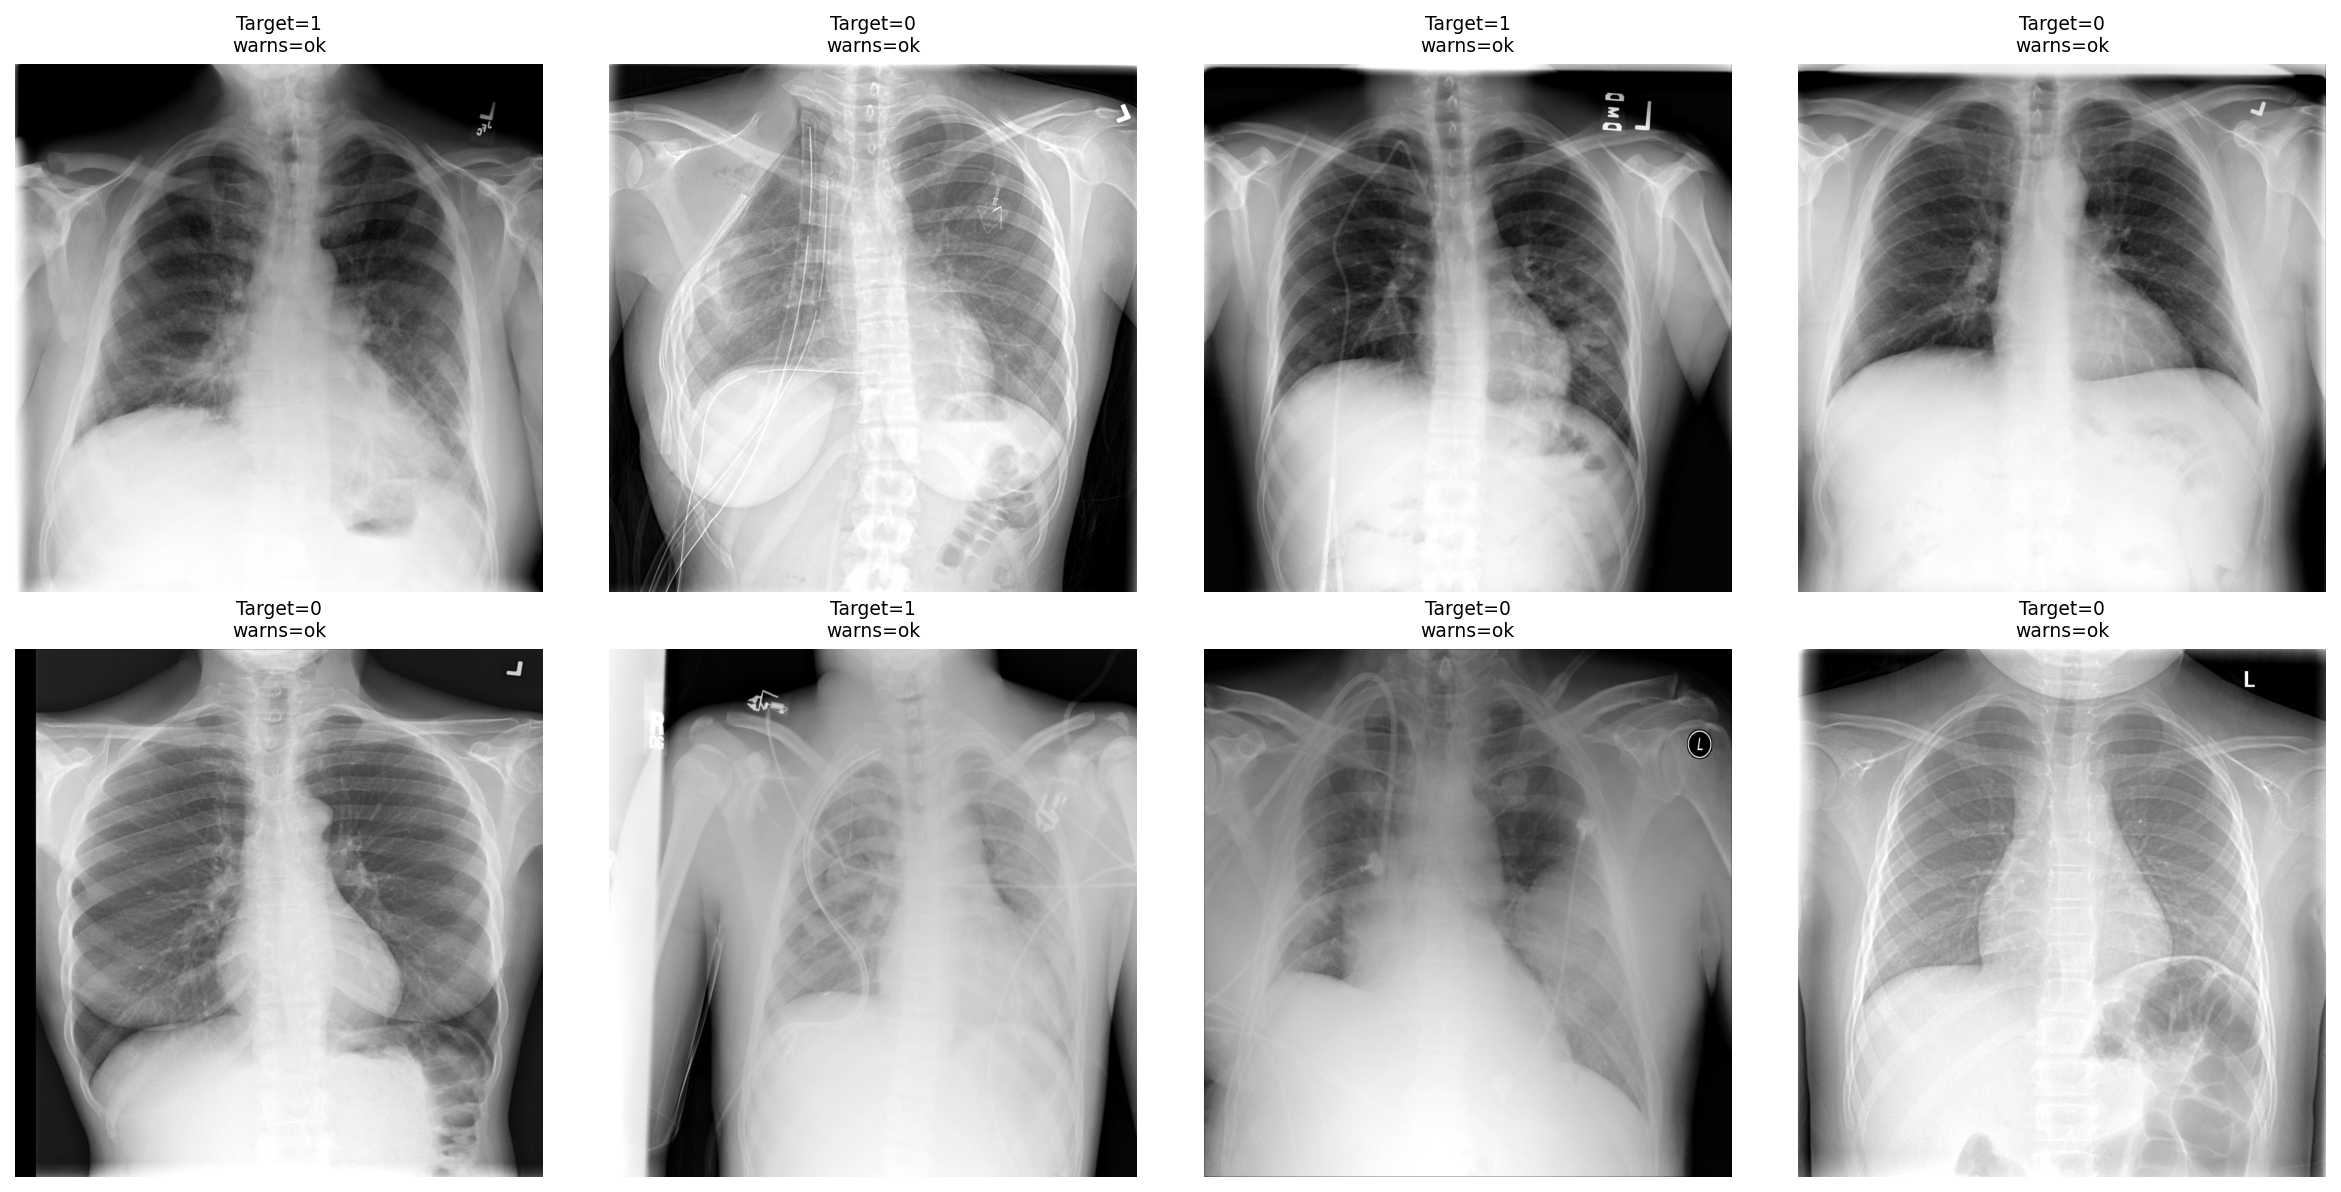

In [9]:
# Visualize sample studies to validate the DICOM preprocessing
sample_fig_path = FIGURES_DIR / "dicom_samples_grid.png"

if not sample_fig_path.exists():
    sample_df = train_df.sample(n=min(8, len(train_df)), random_state=42).reset_index(drop=True)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        dcm, img, arr, meta = read_dicom_as_pil(Path(row["dcm_path"]))
        warns = qc_checks(dcm, arr)
        dims_txt = f"{meta['original_rows']}x{meta['original_columns']}"
        ax.imshow(img, cmap="gray")
        ax.set_title(
            f"Target={int(row['Target'])}\ndims={dims_txt}\nwarns={','.join(warns) if warns else 'ok'}",
            fontsize=9,
        )
        ax.axis("off")
    for ax in axes[len(sample_df):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(sample_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    print("Figura ya existente:", sample_fig_path)
    display(Image.open(sample_fig_path))

## BLOCK 4. Dataset, transforms, and DataLoaders

**Role in the project**
- Prepares the input for training and evaluation.
- It does not belong directly to the final service, although it defines the expected model input behavior.


In [10]:

# Transforms and dataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# HorizontalFlip is intentionally avoided to prevent artificial laterality changes in chest X-rays.
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(7),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class RSNADataset(Dataset):
    def __init__(self, df: pd.DataFrame, tf):
        self.df = df.reset_index(drop=True).copy()
        self.tf = tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        _dcm, img, _arr, _meta = read_dicom_as_pil(Path(row["dcm_path"]))
        x = self.tf(img)
        y = torch.tensor(float(row["Target"]), dtype=torch.float32)
        pid = row["patientId"]
        return x, y, pid

BATCH_SIZE = 32
NUM_WORKERS = 2

train_ds = RSNADataset(train_df, train_tf)
val_ds = RSNADataset(val_df, eval_tf)
test_ds = RSNADataset(test_df, eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

class_counts = train_df["Target"].value_counts().to_dict()
neg_count = class_counts.get(0, 0)
pos_count = class_counts.get(1, 0)
POS_WEIGHT = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32)
print("POS_WEIGHT:", POS_WEIGHT.item())


POS_WEIGHT: 3.084690570831299


## BLOCK 5. Baseline training

**Role in the project**
- This is the most computationally expensive stage.
- Stores per-epoch checkpoints so training can be resumed after interruptions.

**Artifacts from this stage**
- `03_artifacts/checkpoints/last_checkpoint.pt`
- `03_artifacts/checkpoints/best_model.pt`
- `03_artifacts/train_history.csv`


In [11]:

# Model, metrics, and training utilities
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    confusion_matrix
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_probs, all_labels, all_ids = [], [], []
    for x, y, pid in tqdm(loader, desc="predict_loader", leave=False):
        x = x.to(device, non_blocking=True)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(y.numpy().tolist())
        all_ids.extend(list(pid))
    return np.array(all_probs), np.array(all_labels), np.array(all_ids)

def evaluate_model(model, loader, threshold=0.5):
    probs, labels, ids = predict_loader(model, loader)
    metrics = compute_binary_metrics(labels, probs, threshold=threshold)
    return metrics, probs, labels, ids

model = build_model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(device))


device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


In [12]:

# Resume-capable training with per-epoch checkpoints
import csv

EPOCHS = 5
LAST_CKPT_PATH = CHECKPOINTS_DIR / "last_checkpoint.pt"
BEST_MODEL_PATH = CHECKPOINTS_DIR / "best_model.pt"
HISTORY_CSV = ARTIFACTS_DIR / "train_history.csv"

start_epoch = 0
best_val_auc = -1.0
history_rows = []

if HISTORY_CSV.exists():
    history_rows = pd.read_csv(HISTORY_CSV).to_dict(orient="records")
    print(f"Loaded previous training history: {len(history_rows)} rows")

if LAST_CKPT_PATH.exists():
    ckpt = torch.load(LAST_CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    start_epoch = int(ckpt["epoch"]) + 1
    best_val_auc = float(ckpt.get("best_val_auc", -1.0))
    print(f"Resuming from epoch {start_epoch} | best_val_auc={best_val_auc:.4f}")
else:
    print("No last_checkpoint.pt was found; training starts from scratch.")

for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    seen = 0

    loop = tqdm(train_loader, desc=f"train epoch {epoch+1}/{EPOCHS}")
    for x, y, _pid in loop:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x).squeeze(1)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        running_loss += loss.item() * batch_size
        seen += batch_size
        loop.set_postfix(loss=running_loss / max(seen, 1))

    train_loss = running_loss / max(seen, 1)
    val_metrics, _, _, _ = evaluate_model(model, val_loader, threshold=0.5)

    epoch_row = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        **{f"val_{k}": v for k, v in val_metrics.items()}
    }
    history_rows.append(epoch_row)
    pd.DataFrame(history_rows).to_csv(HISTORY_CSV, index=False)

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_auc": best_val_auc,
        "history_csv": str(HISTORY_CSV),
    }, LAST_CKPT_PATH)

    if val_metrics["roc_auc"] > best_val_auc:
        best_val_auc = val_metrics["roc_auc"]
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"[best] epoch={epoch} | val_auc={best_val_auc:.4f}")

    print({
        "epoch": epoch,
        "train_loss": round(train_loss, 5),
        "val_auc": round(val_metrics["roc_auc"], 5),
        "val_pr_auc": round(val_metrics["pr_auc"], 5),
        "val_f1": round(val_metrics["f1"], 5),
    })

print("Entrenamiento finalizado.")
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
print("HISTORY_CSV:", HISTORY_CSV)


Loaded previous training history: 5 rows
Resuming from epoch 5 | best_val_auc=0.8759
Entrenamiento finalizado.
BEST_MODEL_PATH: /content/drive/MyDrive/rsna_service_v3/03_artifacts/checkpoints/best_model.pt
HISTORY_CSV: /content/drive/MyDrive/rsna_service_v3/03_artifacts/train_history.csv


## BLOCK 6. Evaluation and prediction export

**Role in the project**
- Produces metrics and tables for documentation and delivery.
- The artifacts generated here support both the product pipeline and the written report.

**Artifacts from this stage**
- `03_artifacts/val_predictions.csv`
- `03_artifacts/test_predictions.csv`
- `03_artifacts/metrics_summary.json`
- `05_docs/figures/metrics_curves.png`


Recalculando evaluacion final...


{
  "val": {
    "roc_auc": 0.8758514165159734,
    "pr_auc": 0.7138113260045392,
    "accuracy": 0.8016119032858029,
    "f1": 0.6592119275825347,
    "sensitivity": 0.7835443037974683,
    "specificity": 0.8074712643678161,
    "tn": 1967,
    "fp": 469,
    "fn": 171,
    "tp": 619
  },
  "test": {
    "roc_auc": 0.8650153693748817,
    "pr_auc": 0.6760387284933108,
    "accuracy": 0.7987596899224806,
    "f1": 0.6534970635344367,
    "sensitivity": 0.7756653992395437,
    "specificity": 0.80623973727422,
    "tn": 1964,
    "fp": 472,
    "fn": 177,
    "tp": 612
  }
}
Guardados: /content/drive/MyDrive/rsna_service_v3/03_artifacts/val_predictions.csv /content/drive/MyDrive/rsna_service_v3/03_artifacts/test_predictions.csv /content/drive/MyDrive/rsna_service_v3/03_artifacts/metrics_summary.json /content/drive/MyDrive/rsna_service_v3/05_docs/tables/metrics_summary.csv


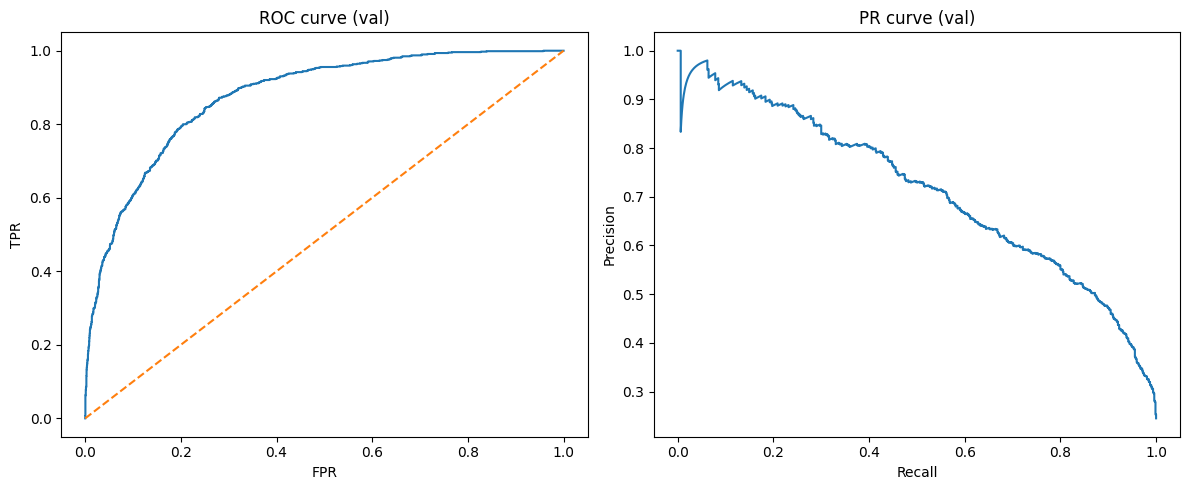

Guardado: /content/drive/MyDrive/rsna_service_v3/05_docs/figures/metrics_curves.png
Listo: /content/drive/MyDrive/rsna_service_v3/05_docs/tables/metrics_summary.csv


In [18]:
# Final evaluation on validation and test sets, with prediction and metric export
from sklearn.metrics import roc_curve, precision_recall_curve

val_pred_path = ARTIFACTS_DIR / "val_predictions.csv"
test_pred_path = ARTIFACTS_DIR / "test_predictions.csv"
metrics_path = ARTIFACTS_DIR / "metrics_summary.json"
curve_fig_path = FIGURES_DIR / "metrics_curves.png"
metrics_table_path = TABLES_DIR / "metrics_summary.csv"

# Change to True only if you want to force a full reevaluation
FORCE_REEVAL = False

cache_ready = (
    val_pred_path.exists()
    and test_pred_path.exists()
    and metrics_path.exists()
    and metrics_table_path.exists()
)

if cache_ready and not FORCE_REEVAL:
    print("Using previously saved evaluation artifacts...")

    val_pred_df = pd.read_csv(val_pred_path)
    test_pred_df = pd.read_csv(test_pred_path)

    metrics_summary = json.loads(metrics_path.read_text(encoding="utf-8"))
    val_metrics = metrics_summary["val"]
    test_metrics = metrics_summary["test"]

    val_probs = val_pred_df["probability"].to_numpy()
    val_labels = val_pred_df["label"].to_numpy()
    val_ids = val_pred_df["patientId"].to_numpy()

    test_probs = test_pred_df["probability"].to_numpy()
    test_labels = test_pred_df["label"].to_numpy()
    test_ids = test_pred_df["patientId"].to_numpy()

    print(json.dumps(metrics_summary, indent=2))
    print("Loaded:", val_pred_path, test_pred_path, metrics_path)

else:
    print("Recalculating final eval...")

    model = build_model().to(device)
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    model.eval()

    val_metrics, val_probs, val_labels, val_ids = evaluate_model(model, val_loader, threshold=0.5)
    test_metrics, test_probs, test_labels, test_ids = evaluate_model(model, test_loader, threshold=0.5)

    val_pred_df = pd.DataFrame({
        "patientId": val_ids,
        "label": val_labels.astype(int),
        "probability": val_probs,
    }).merge(
        val_df[["patientId", "dcm_path"]].drop_duplicates(),
        on="patientId",
        how="left",
    )
    test_pred_df = pd.DataFrame({
        "patientId": test_ids,
        "label": test_labels.astype(int),
        "probability": test_probs,
    }).merge(
        test_df[["patientId", "dcm_path"]].drop_duplicates(),
        on="patientId",
        how="left",
    )

    def attach_original_dims(df: pd.DataFrame) -> pd.DataFrame:
        rows_list, cols_list = [], []
        for p in df["dcm_path"]:
            try:
                _dcm, _img, _arr, _meta = read_dicom_as_pil(Path(p))
                rows_list.append(_meta["original_rows"])
                cols_list.append(_meta["original_columns"])
            except Exception:
                rows_list.append(None)
                cols_list.append(None)
        df = df.copy()
        df["original_rows"] = rows_list
        df["original_columns"] = cols_list
        return df.drop(columns=["dcm_path"])

    val_pred_df = attach_original_dims(val_pred_df)
    test_pred_df = attach_original_dims(test_pred_df)

    val_pred_df.to_csv(val_pred_path, index=False)
    test_pred_df.to_csv(test_pred_path, index=False)

    metrics_summary = {"val": val_metrics, "test": test_metrics}
    metrics_path.write_text(json.dumps(metrics_summary, indent=2), encoding="utf-8")

    pd.DataFrame([
        {"split": "val", **val_metrics},
        {"split": "test", **test_metrics},
    ]).to_csv(metrics_table_path, index=False)

    print(json.dumps(metrics_summary, indent=2))
    print("Saved:", val_pred_path, test_pred_path, metrics_path, metrics_table_path)

# Curvas: se regeneran solo si no existen o si se fuerza la reevaluacion
if FORCE_REEVAL or not curve_fig_path.exists():
    fpr, tpr, _ = roc_curve(val_labels, val_probs)
    precision, recall, _ = precision_recall_curve(val_labels, val_probs)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC curve (val)")

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("PR curve (val)")
    plt.tight_layout()
    plt.savefig(curve_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
 #   plt.close()

    print("Saved:", curve_fig_path)
else:
    print("Using saved curve:", curve_fig_path)

print("Ready:", metrics_table_path)

## BLOCK 7. Calibration and operating threshold

**Role in the project**
- Adjusts probabilities for more reliable runtime usage.
- Exports temperature and threshold as artifacts consumed by the service.

**Artifacts from this stage**
- `03_artifacts/temperature.json`
- `03_artifacts/threshold.json`
- `03_artifacts/calibration_metrics.json`


In [14]:

# Temperature scaling on validation logits
import torch.nn.functional as F

TEMPERATURE_PATH = ARTIFACTS_DIR / "temperature.json"
CALIBRATION_METRICS_PATH = ARTIFACTS_DIR / "calibration_metrics.json"

@torch.no_grad()
def collect_logits_and_labels(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for x, y, _pid in tqdm(loader, desc="collect logits", leave=False):
        x = x.to(device, non_blocking=True)
        logits = model(x).squeeze(1)
        all_logits.append(logits.detach())
        all_labels.append(y.to(device))
    return torch.cat(all_logits), torch.cat(all_labels)

if TEMPERATURE_PATH.exists():
    temp_payload = json.loads(TEMPERATURE_PATH.read_text(encoding="utf-8"))
    best_T = float(temp_payload["temperature"])
    print("Reused temperature:", best_T)
else:
    logits, labels = collect_logits_and_labels(model, val_loader)

    def nll_with_T(logits, labels, T):
        return F.binary_cross_entropy_with_logits(logits / T, labels)

    Ts = torch.linspace(0.5, 5.0, steps=46).to(device)
    best_T, best_loss = None, 1e9
    for T in Ts:
        loss = nll_with_T(logits, labels, T)
        if loss.item() < best_loss:
            best_loss = float(loss.item())
            best_T = float(T.item())

    TEMPERATURE_PATH.write_text(
        json.dumps({"temperature": best_T}, indent=2),
        encoding="utf-8"
    )
    CALIBRATION_METRICS_PATH.write_text(
        json.dumps({"val_nll_best_temperature": best_loss}, indent=2),
        encoding="utf-8"
    )
    print("New calculated temperature:", best_T)


Temperatura reutilizada: 0.8999999761581421


In [15]:

# Select the operating threshold on validation data and save it
THRESHOLD_PATH = ARTIFACTS_DIR / "threshold.json"

val_probs_cal = 1.0 / (1.0 + np.exp(-(np.log(val_probs / np.clip(1 - val_probs, 1e-8, 1.0)) / best_T)))
threshold_candidates = np.linspace(0.1, 0.9, 17)

best_thr = 0.5
best_score = -1.0
rows = []

for thr in threshold_candidates:
    m = compute_binary_metrics(val_labels, val_probs_cal, threshold=float(thr))
    rows.append({"threshold": float(thr), **m})
    score = 0.5 * (m["sensitivity"] + m["specificity"])
    if score > best_score:
        best_score = score
        best_thr = float(thr)

threshold_df = pd.DataFrame(rows)
threshold_table_path = TABLES_DIR / "threshold_search.csv"
threshold_df.to_csv(threshold_table_path, index=False)

THRESHOLD_PATH.write_text(
    json.dumps({"threshold": best_thr, "selection_rule": "max_mean_sensitivity_specificity_on_val"}, indent=2),
    encoding="utf-8"
)

print("best_T:", best_T)
print("best_threshold:", best_thr)
print("Saved:", THRESHOLD_PATH, threshold_table_path)


best_T: 0.8999999761581421
best_threshold: 0.4
Guardados: /content/drive/MyDrive/rsna_service_v3/03_artifacts/threshold.json /content/drive/MyDrive/rsna_service_v3/05_docs/tables/threshold_search.csv


## BLOCK 8. Explainability with Grad-CAM

**Role in the project**
- Produces figures for documentation and a visual reference for the service outputs.
- It does not replace detection or segmentation; it is qualitative evidence.

**Artifacts from this stage**
- Images under `05_docs/figures/gradcam_*.png`


In [16]:
# Grad-CAM and export of representative examples
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.h1 = target_layer.register_forward_hook(self._forward_hook)
        self.h2 = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def close(self):
        self.h1.remove()
        self.h2.remove()

    def __call__(self, x):
        self.model.zero_grad(set_to_none=True)
        logit = self.model(x).squeeze(1)
        logit.backward(torch.ones_like(logit))
        acts = self.activations
        grads = self.gradients
        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def overlay_cam_on_rgb(rgb_uint8: np.ndarray, cam: np.ndarray, alpha=0.35):
    heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    out = np.clip((1 - alpha) * rgb_uint8 + alpha * heat, 0, 255).astype(np.uint8)
    return out

gradcam = GradCAM(model, model.layer4[-1].conv2)

examples = pd.concat([
    val_df[val_df["Target"] == 1].head(2),
    val_df[val_df["Target"] == 0].head(2),
], axis=0).reset_index(drop=True)

for _, row in examples.iterrows():
    _dcm, pil_img, _arr, _meta = read_dicom_as_pil(Path(row["dcm_path"]))
    x = eval_tf(pil_img).unsqueeze(0).to(device)
    cam = gradcam(x)
    rgb = np.array(pil_img.resize((224, 224)))
    overlay = overlay_cam_on_rgb(rgb, cam, alpha=0.35)

    out_path = FIGURES_DIR / f"gradcam_{row['patientId']}_target_{int(row['Target'])}.png"
    Image.fromarray(overlay).save(out_path)
    print("Saved:", out_path)

gradcam.close()

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Guardado: /content/drive/MyDrive/rsna_service_v3/05_docs/figures/gradcam_1703df50-8138-4f31-bf88-737846994074_target_1.png
Guardado: /content/drive/MyDrive/rsna_service_v3/05_docs/figures/gradcam_604a0eca-1494-47b8-a49b-713d24d070f9_target_1.png
Guardado: /content/drive/MyDrive/rsna_service_v3/05_docs/figures/gradcam_40eaca23-ac68-4025-98d5-f62100c04350_target_0.png
Guardado: /content/drive/MyDrive/rsna_service_v3/05_docs/figures/gradcam_bf728b6f-7253-4872-bb67-2113b423652e_target_0.png


## BLOCK 9. Final local demo with study metadata

{'case_title': 'Positive case', 'patientId': '1703df50-8138-4f31-bf88-737846994074', 'true_label': 1, 'predicted_label': 1, 'calibrated_probability': 0.88343, 'threshold': 0.4, 'qc_warnings': [], 'original_rows': 1024, 'original_columns': 1024, 'modality': 'CR', 'photometric_interpretation': 'MONOCHROME2'}


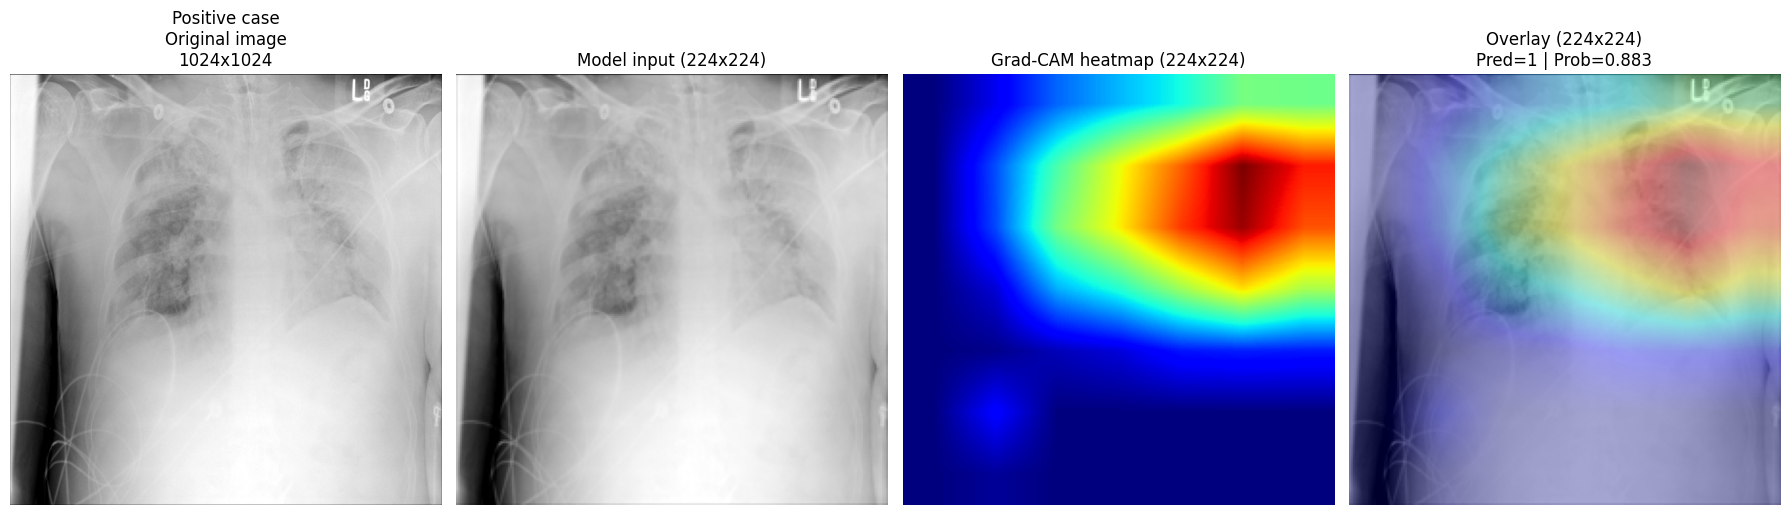

{'case_title': 'Negative case', 'patientId': '40eaca23-ac68-4025-98d5-f62100c04350', 'true_label': 0, 'predicted_label': 0, 'calibrated_probability': 0.18562, 'threshold': 0.4, 'qc_warnings': [], 'original_rows': 1024, 'original_columns': 1024, 'modality': 'CR', 'photometric_interpretation': 'MONOCHROME2'}


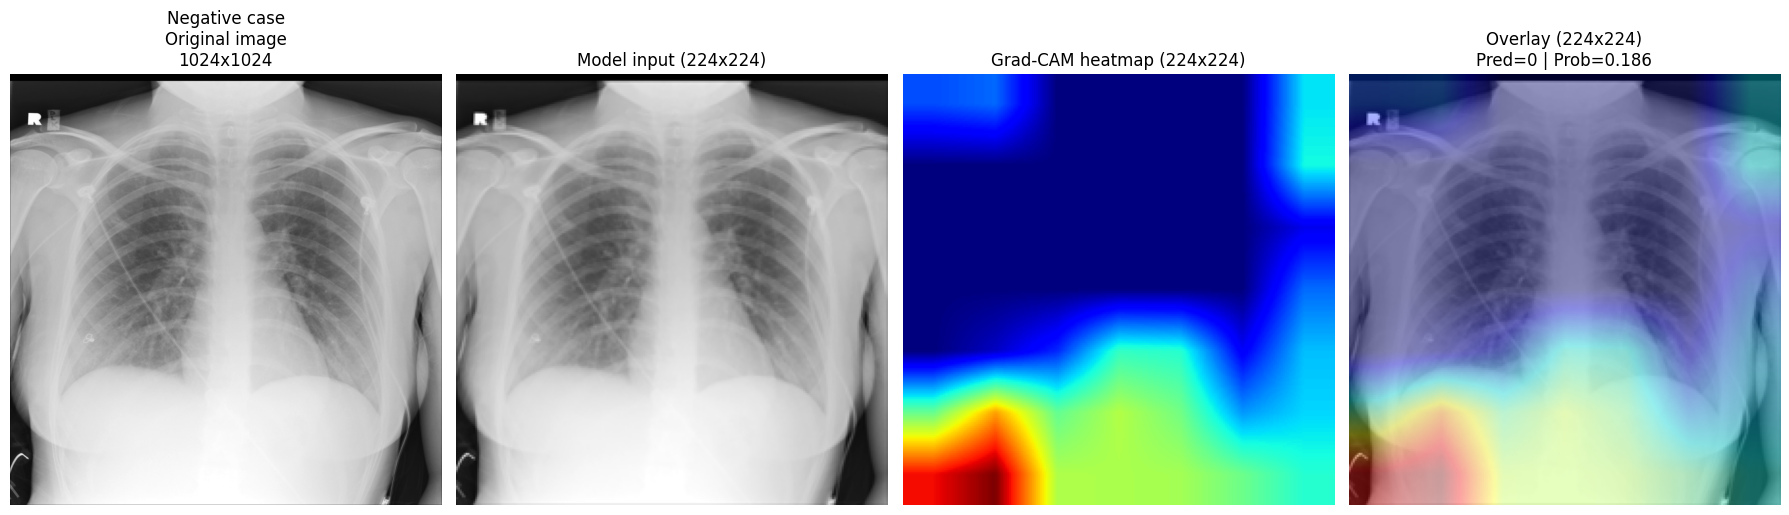

In [17]:
# Final dual local demo: one positive case and one negative case with Grad-CAM
best_model = build_model().to(device)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
best_model.eval()

gradcam_demo = GradCAM(best_model, best_model.layer4[-1].conv2)

def _read_dicom_with_optional_meta(path_obj):
    out = read_dicom_as_pil(path_obj)
    if isinstance(out, tuple) and len(out) == 4:
        dcm, pil_img, arr, meta = out
    elif isinstance(out, tuple) and len(out) == 3:
        dcm, pil_img, arr = out
        meta = {
            "original_rows": int(getattr(dcm, "Rows", arr.shape[0])),
            "original_columns": int(getattr(dcm, "Columns", arr.shape[1])),
            "photometric_interpretation": getattr(dcm, "PhotometricInterpretation", None),
            "modality": getattr(dcm, "Modality", None),
            "study_instance_uid": getattr(dcm, "StudyInstanceUID", None),
            "series_instance_uid": getattr(dcm, "SeriesInstanceUID", None),
            "sop_instance_uid": getattr(dcm, "SOPInstanceUID", None),
        }
    else:
        raise ValueError("Unexpected return format from read_dicom_as_pil(...)")
    return dcm, pil_img, arr, meta

def _run_demo_case(case_row, case_title):
    dcm, pil_img, arr, meta = _read_dicom_with_optional_meta(Path(case_row["dcm_path"]))
    warnings = qc_checks(dcm, arr)

    x = eval_tf(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = best_model(x).squeeze(1)
        calibrated_prob = torch.sigmoid(logits / best_T).item()

    pred_label = int(calibrated_prob >= best_thr)

    cam = gradcam_demo(x)
    rgb_224 = np.array(pil_img.resize((224, 224)))
    overlay_224 = overlay_cam_on_rgb(rgb_224, cam, alpha=0.35)

    summary = {
        "case_title": case_title,
        "patientId": case_row["patientId"],
        "true_label": int(case_row["Target"]),
        "predicted_label": pred_label,
        "calibrated_probability": round(calibrated_prob, 5),
        "threshold": float(best_thr),
        "qc_warnings": warnings,
        "original_rows": meta.get("original_rows"),
        "original_columns": meta.get("original_columns"),
        "modality": meta.get("modality"),
        "photometric_interpretation": meta.get("photometric_interpretation"),
    }
    print(summary)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(np.array(pil_img))
    axes[0].set_title(
        f"{case_title}\nOriginal image\n{meta.get('original_columns')}x{meta.get('original_rows')}"
    )
    axes[0].axis("off")

    axes[1].imshow(rgb_224)
    axes[1].set_title("Model input (224x224)")
    axes[1].axis("off")

    axes[2].imshow(cam, cmap="jet")
    axes[2].set_title("Grad-CAM heatmap (224x224)")
    axes[2].axis("off")

    axes[3].imshow(overlay_224)
    axes[3].set_title(
        f"Overlay (224x224)\nPred={pred_label} | Prob={calibrated_prob:.3f}"
    )
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

# Pick one positive and one negative example from validation
pos_candidates = val_df[val_df["Target"] == 1]
neg_candidates = val_df[val_df["Target"] == 0]

if len(pos_candidates) == 0 or len(neg_candidates) == 0:
    raise ValueError("Validation split does not contain both positive and negative samples.")

positive_row = pos_candidates.iloc[0]
negative_row = neg_candidates.iloc[0]

_run_demo_case(positive_row, "Positive case")
_run_demo_case(negative_row, "Negative case")

gradcam_demo.close()